In [2]:
# ============================================================
# FILE: notebooks/01_eda.py
# PURPOSE: Exploratory Data Analysis — run cell by cell in
#          VS Code (Jupyter) or as a plain Python script.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Style ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = r"C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File\career_dataset_realistic.csv"
df = pd.read_csv(DATA_PATH)



In [3]:
# ══════════════════════════════════════════════════════════════
# 1. BASIC OVERVIEW
# ══════════════════════════════════════════════════════════════
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())



Shape: (1010, 11)

First 5 rows:
   Student_ID              Interest Primary_Skill  Coding_Score  Math_Score  \
0           1  Software Development        Python            70          59   
1           2       Web Development         Linux            69          95   
2           3       Cloud Computing          Java            61          98   
3           4  Software Development    Networking            68          66   
4           5       Cloud Computing    Networking            96          52   

   Communication_Score  Projects_Count  Certifications_Count  GitHub_Score  \
0                   69               8                     0            53   
1                   72               4                     3            79   
2                   98              10                     3            85   
3                   86               4                     5            53   
4                   80               9                     2            88   

  Personality_Type     

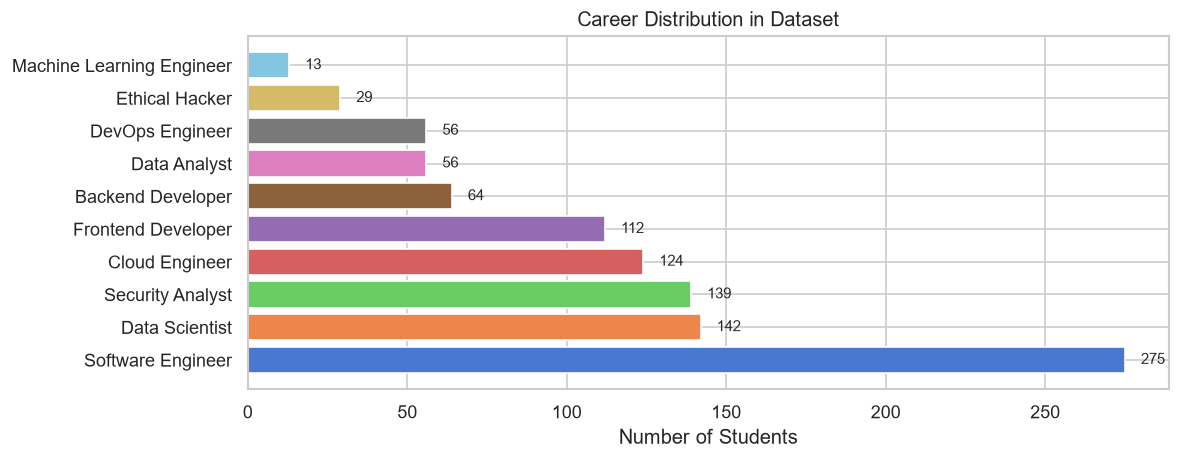

In [4]:
# ══════════════════════════════════════════════════════════════
# 2. TARGET DISTRIBUTION — Career
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
career_counts = df["Career"].value_counts()
bars = ax.barh(career_counts.index, career_counts.values, color=sns.color_palette("muted", len(career_counts)))
ax.set_xlabel("Number of Students")
ax.set_title("Career Distribution in Dataset")
for bar, val in zip(bars, career_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("career_distribution.png")
plt.show()



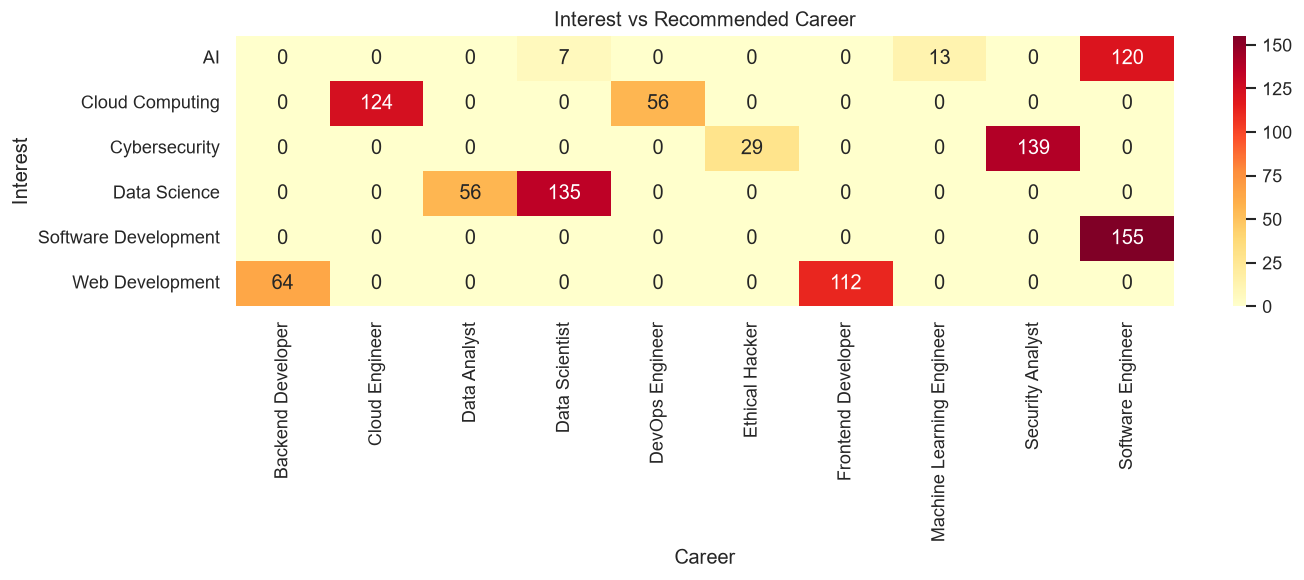

In [5]:
# ══════════════════════════════════════════════════════════════
# 3. INTEREST vs CAREER — Heatmap
# ══════════════════════════════════════════════════════════════
if "Interest" in df.columns:
    ct = pd.crosstab(df["Interest"], df["Career"])
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title("Interest vs Recommended Career")
    plt.tight_layout()
    plt.savefig("interest_vs_career.png")
    plt.show()



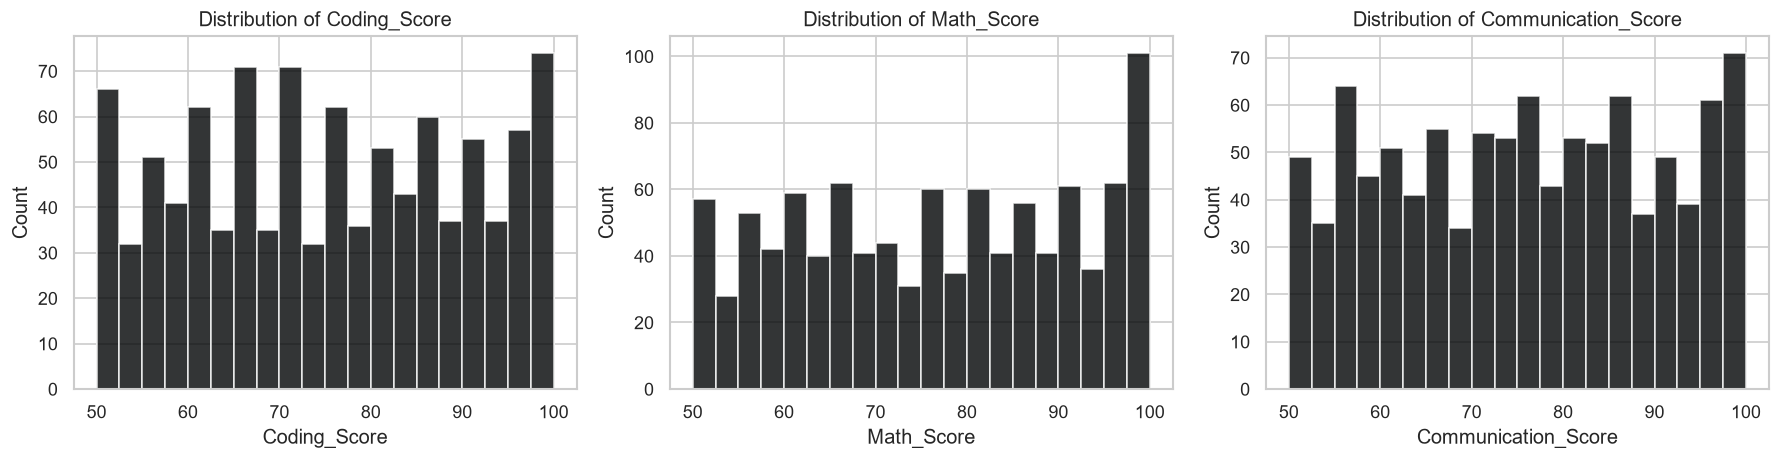

In [6]:
# ══════════════════════════════════════════════════════════════
# 4. SCORE DISTRIBUTIONS
# ══════════════════════════════════════════════════════════════
score_cols = [c for c in ["Coding_Score", "Math_Score", "Communication_Score"] if c in df.columns]
if score_cols:
    fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 4))
    if len(score_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, score_cols):
        ax.hist(df[col].dropna(), bins=20, color="#000203", edgecolor="white", alpha=0.8)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig("score_distributions.png")
    plt.show()



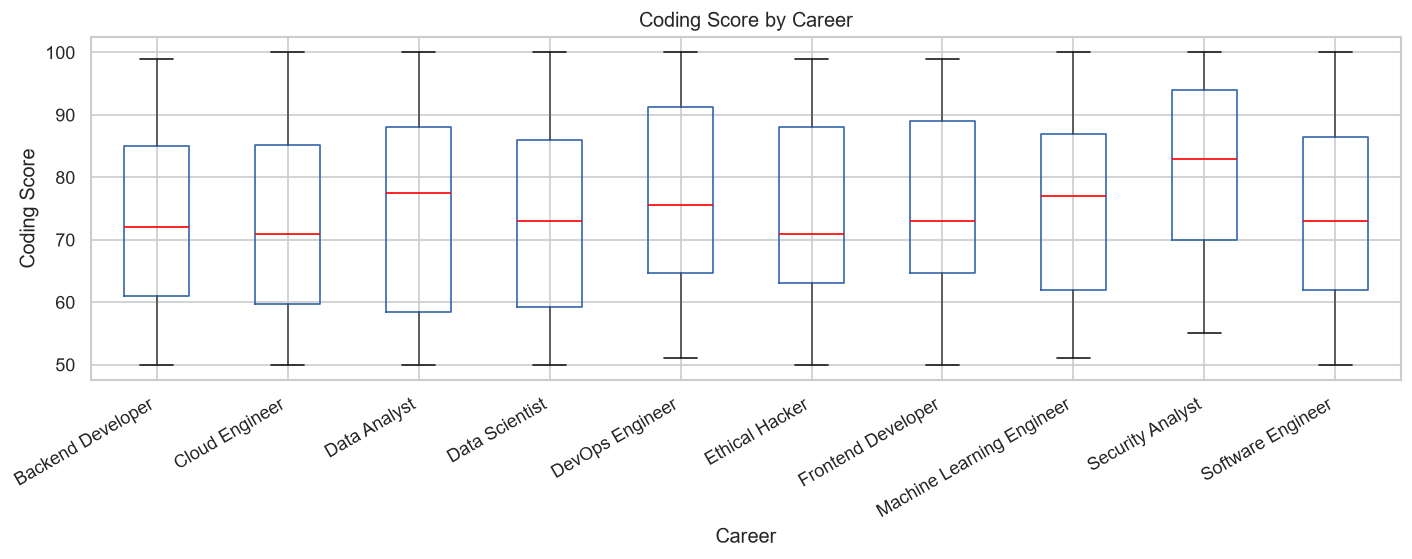

In [7]:
# ══════════════════════════════════════════════════════════════
# 5. BOXPLOT — Scores per Career
# ══════════════════════════════════════════════════════════════
if "Coding_Score" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    df.boxplot(column="Coding_Score", by="Career", ax=ax, 
               boxprops=dict(color="#3266ad"), medianprops=dict(color="red"))
    ax.set_title("Coding Score by Career")
    plt.suptitle("")
    ax.set_xlabel("Career")
    ax.set_ylabel("Coding Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("coding_by_career.png")
    plt.show()



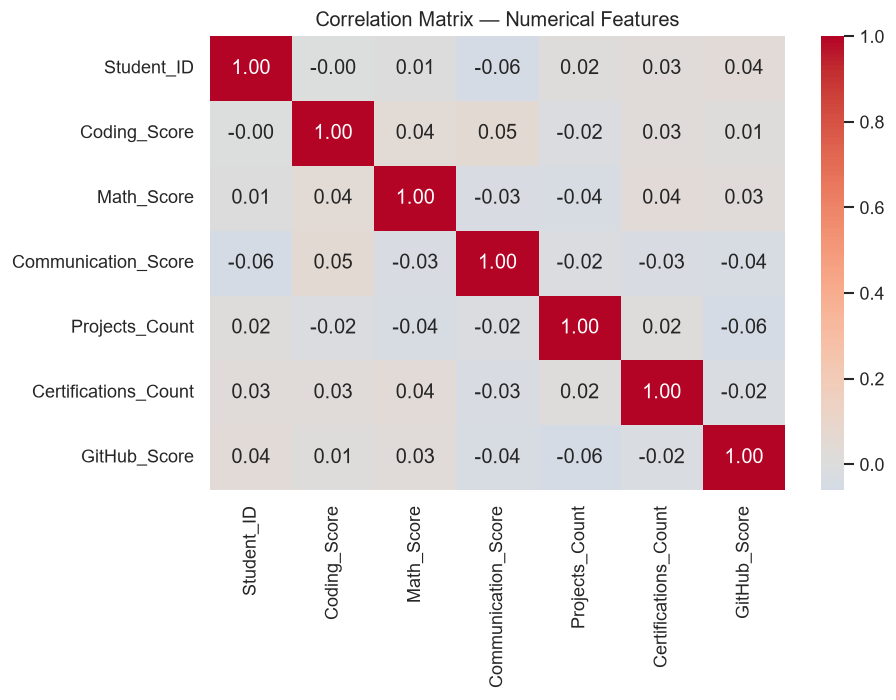

In [8]:
# ══════════════════════════════════════════════════════════════
# 6. CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════
num_df = df.select_dtypes(include=["int64", "float64"])
if not num_df.empty:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, center=0)
    ax.set_title("Correlation Matrix — Numerical Features")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png")
    plt.show()



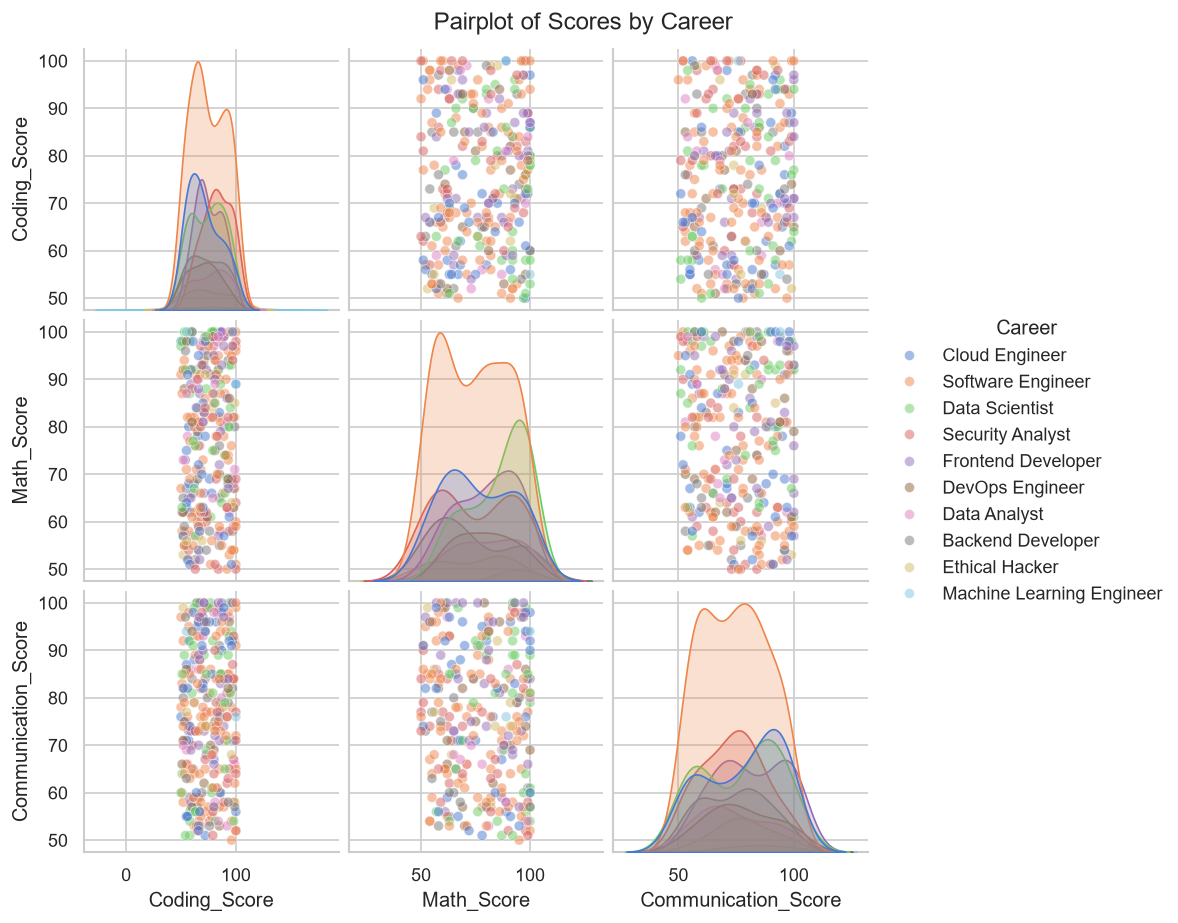

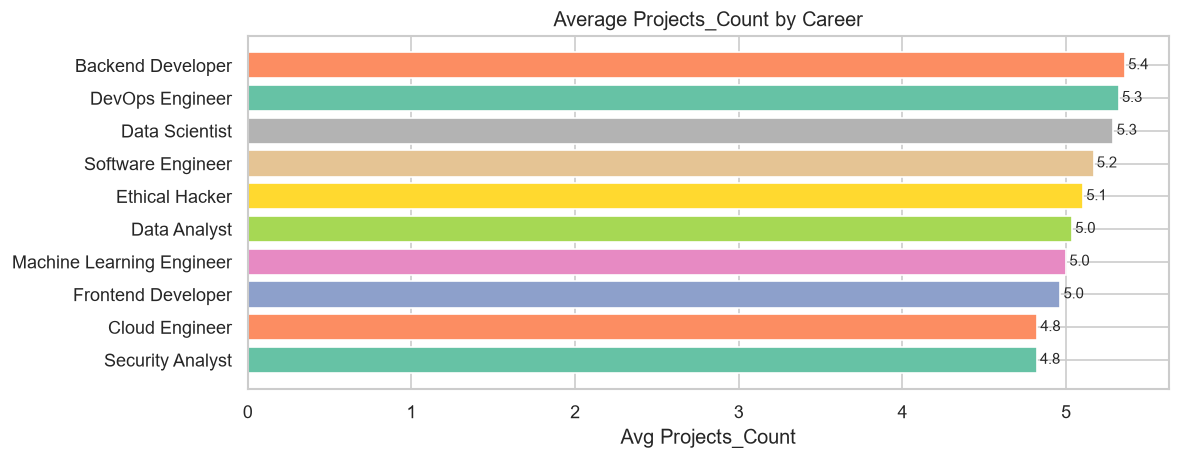

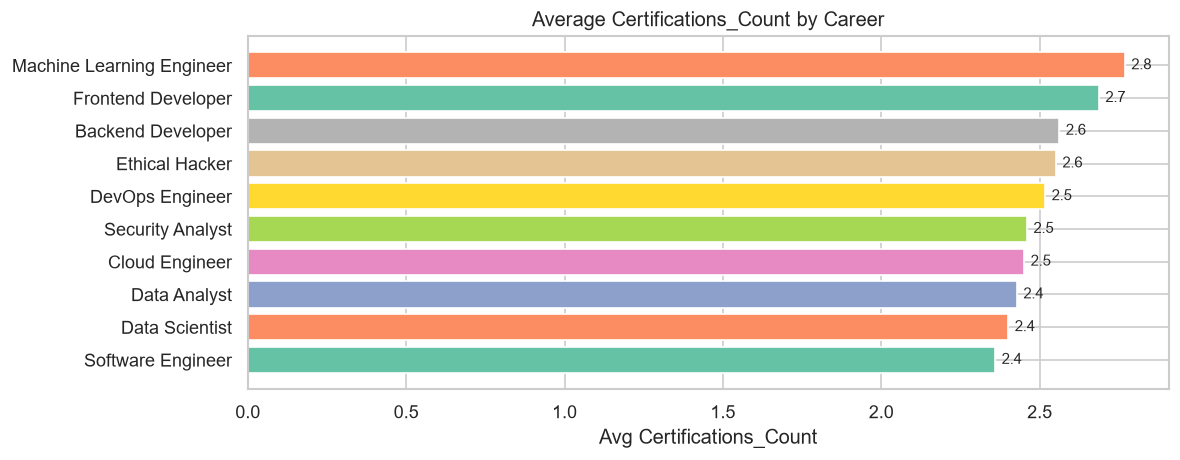


✅ EDA complete. All charts saved as PNG files.


In [9]:
# ══════════════════════════════════════════════════════════════
# 7. PAIRPLOT (Sample for clarity)
# ══════════════════════════════════════════════════════════════
if score_cols and "Career" in df.columns:
    sample = df[score_cols + ["Career"]].sample(min(300, len(df)), random_state=42)
    g = sns.pairplot(sample, hue="Career", diag_kind="kde", plot_kws={"alpha": 0.5})
    g.fig.suptitle("Pairplot of Scores by Career", y=1.02)
    plt.savefig("pairplot.png")
    plt.show()

# ══════════════════════════════════════════════════════════════
# 8. PROJECTS & CERTIFICATIONS
# ══════════════════════════════════════════════════════════════
for col in ["Projects_Count", "Certifications_Count"]:
    if col in df.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        avg = df.groupby("Career")[col].mean().sort_values(ascending=True)
        bars = ax.barh(avg.index, avg.values, color=sns.color_palette("Set2", len(avg)))
        ax.set_title(f"Average {col} by Career")
        ax.set_xlabel(f"Avg {col}")
        for bar, val in zip(bars, avg.values):
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center", fontsize=9)
        plt.tight_layout()
        plt.savefig(f"{col.lower()}_by_career.png")
        plt.show()

print("\n✅ EDA complete. All charts saved as PNG files.")